# Auditoria da completude temporal da arrecadação por UF

Material de apoio ao trabalho de Giovanni Brígido. Fonte oficial: Receita Federal do Brasil. Recorte: janeiro/2000 a dezembro/2025.

Objetivo: distinguir ausências previstas pelo dicionário de lacunas em colunas aplicáveis. Não avalia evasão, regularidade tributária, exatidão dos valores ou desempenho de UFs. O e-mail e a revisão do autor permanecem pendentes.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

RAIZ = Path.cwd()
if not (RAIZ / 'config/regras_temporais.json').exists():
    RAIZ = RAIZ / '10-adap/assignments/final-giovanni'
assert (RAIZ / 'config/regras_temporais.json').exists(), 'Abra o notebook na raiz do projeto.'
sys.path.insert(0, str(RAIZ / 'scripts'))
import baixar_dados
import analisar_qualidade
import validar_controles

## 1. Fonte e proveniência

O CSV e o dicionário são baixados sem chave. As execuções seguintes verificam SHA-256 e reutilizam a cópia congelada. O manifesto também registra horário e URL. Não substituir os originais para simular defeitos.

In [2]:
baixar_dados.main()
proveniencia = json.loads((RAIZ / 'dados/proveniencia.json').read_text())
display(pd.DataFrame(proveniencia)[['arquivo','bytes','sha256','coletado_em_utc']])
df = analisar_qualidade.ler()
display(pd.Series({'linhas_arquivo':len(df),'colunas_arquivo':len(df.columns)}))

Cópia congelada verificada; nenhum download necessário.


,arquivo,bytes,sha256,coletado_em_utc
0,arrecadacao-estado.csv,2407961,e4fdc308fa3b4dbce4ba1b6ad988123f272dd325c83578...,2026-09-05T14:17:53.538678+00:00
1,arrecadacao-estado-metadados.pdf,127074,44ee7e5208227e1863076e7fc8054b2b39151add7e770e...,2026-09-05T14:17:54.113874+00:00


linhas_arquivo     8613
colunas_arquivo      45
dtype: int64

## 2. Regras independentes dos vazios observados

Os nove intervalos foram transcritos das páginas 2 e 3 do dicionário. São intervalos de publicação de colunas, não de vigência jurídica de tributos. As categorias agregadas encerram-se em dezembro/2003; as categorias Financeiras e Demais começam em janeiro/2004. As outras 33 colunas de valores têm somente controle lexical.

In [3]:
config = json.loads((RAIZ / 'config/regras_temporais.json').read_text())
display(pd.DataFrame(config['regras']))

,coluna,inicio,fim
0,COFINS,2000-01-01,2003-12-01
1,COFINS - FINANCEIRAS,2004-01-01,NaN
2,COFINS - DEMAIS,2004-01-01,NaN
3,CONTRIBUIÇÃO PARA O PIS/PASEP,2000-01-01,2003-12-01
4,CONTRIBUIÇÃO PARA O PIS/PASEP - FINANCEIRAS,2004-01-01,NaN
5,CONTRIBUIÇÃO PARA O PIS/PASEP - DEMAIS,2004-01-01,NaN
6,CSLL,2000-01-01,2003-12-01
7,CSLL - FINANCEIRAS,2004-01-01,NaN
8,CSLL - DEMAIS,2004-01-01,NaN


## 3. Executar a auditoria

As rotinas validam a chave ano–mês–UF, o painel de 312 meses × 27 UFs, formatos e presença condicionada. Cada célula das nove colunas recebe uma classificação. Zero é preenchimento; ausência fora do intervalo é preservada. O CSV inclui meses de 2026, excluídos do recorte temporal.

O controle lexical reconhece duas convenções numéricas, mas não resolve sua ambiguidade nem converte os valores para soma. Presença e formato não garantem exatidão.

In [4]:
analisar_qualidade.main()
resumo = json.loads((RAIZ / 'resultados/resumo.json').read_text())
display(pd.read_csv(RAIZ / 'resultados/completude_por_coluna.csv'))
display(pd.read_csv(RAIZ / 'resultados/ocorrencias.csv'))

{
  "registros_arquivo": 8613,
  "colunas_arquivo": 45,
  "registros_recorte": 8424,
  "meses_recorte": 312,
  "ufs": 27,
  "painel_completo": true,
  "regras_temporais": 9,
  "celulas_avaliadas": 75816,
  "celulas_aplicaveis": 46656,
  "ausencias_ingenuas": 29160,
  "ausencias_previstas": 29160,
  "ausencias_aplicaveis": 0,
  "presencas_fora_intervalo": 0,
  "ocorrencias": 0,
  "formatos_apenas_en": 5625,
  "formatos_ambiguos": 3120,
  "regras_sha256": "950235407d89bf564d7ddb007753bbdb0880ac2ea8b9089c0e0154b5b6c76e59",
  "script_sha256": "bb6278a2d6fcfcbfec54f31ee4ed8d0e0c8c90c709858198f31cdc9f52bd0db8",
  "completude_ingenua_pct": 61.53846153846154,
  "completude_condicionada_pct": 100.0
}


,coluna,celulas,aplicaveis,ausencias_ingenuas,ausencias_previstas,ausencias_aplicaveis,presencas_fora_intervalo
0,COFINS,8424,1296,7128,7128,0,0
1,COFINS - FINANCEIRAS,8424,7128,1296,1296,0,0
2,COFINS - DEMAIS,8424,7128,1296,1296,0,0
3,CONTRIBUIÇÃO PARA O PIS/PASEP,8424,1296,7128,7128,0,0
4,CONTRIBUIÇÃO PARA O PIS/PASEP - FINANCEIRAS,8424,7128,1296,1296,0,0
5,CONTRIBUIÇÃO PARA O PIS/PASEP - DEMAIS,8424,7128,1296,1296,0,0
6,CSLL,8424,1296,7128,7128,0,0
7,CSLL - FINANCEIRAS,8424,7128,1296,1296,0,0
8,CSLL - DEMAIS,8424,7128,1296,1296,0,0


,linha_csv,ano,mes,uf,regra,coluna,valor


## 4. Comparar os denominadores

A medida simples divide células preenchidas por todas as células; a medida temporal considera somente as células aplicáveis. A mudança percentual não decorre de correção ou imputação de dados. Todos os resultados são condicionais às nove regras e ao snapshot preservado.

,medida,percentual
0,Completude simples,61.538462
1,Completude condicionada,100.000000


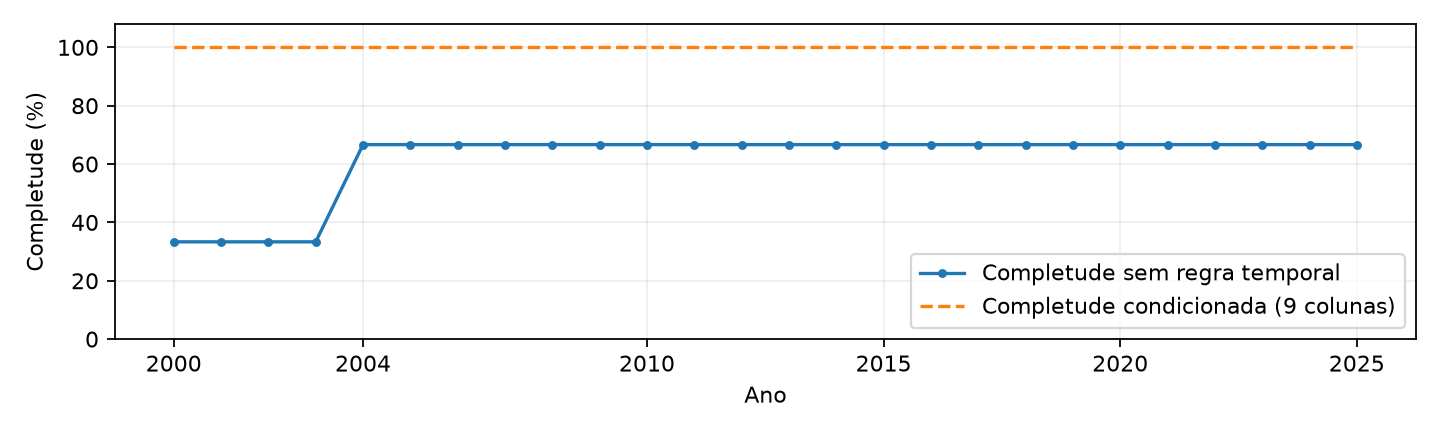

In [5]:
display(pd.DataFrame({
    'medida':['Completude simples','Completude condicionada'],
    'percentual':[resumo['completude_ingenua_pct'],resumo['completude_condicionada_pct']]
}))
display(Image(filename=str(RAIZ / 'figuras/completude.png')))

## 5. Testes controlados

Os 13 testes alteram cópias em memória e comparam o conjunto exato das classes de ocorrência. Não se confundem com validação externa ou estimativas de precisão em defeitos reais. Os casos sem defeito, zero e negativos verificam se o detector evita alertas injustificados.

In [6]:
validar_controles.main()
display(pd.read_csv(RAIZ / 'resultados/testes_controlados.csv'))

             cenario                    esperado                   observado  aprovado
         sem_mutacao                                                              True
      nulo_aplicavel          ausencia_aplicavel          ausencia_aplicavel      True
valor_fora_intervalo     presenca_fora_intervalo     presenca_fora_intervalo      True
     numero_invalido             numero_invalido             numero_invalido      True
        mes_invalido chave_ausente;data_invalida chave_ausente;data_invalida      True
         uf_invalida   chave_ausente;uf_invalida   chave_ausente;uf_invalida      True
       zero_legitimo                                                              True
      milhar_decimal                                                              True
      sinal_negativo                                                              True
limite_dezembro_2003          ausencia_aplicavel          ausencia_aplicavel      True
 limite_janeiro_2004          ausencia_apli

,cenario,esperado,observado,aprovado
0,sem_mutacao,NaN,NaN,True
1,nulo_aplicavel,ausencia_aplicavel,ausencia_aplicavel,True
2,valor_fora_intervalo,presenca_fora_intervalo,presenca_fora_intervalo,True
3,numero_invalido,numero_invalido,numero_invalido,True
4,mes_invalido,chave_ausente;data_invalida,chave_ausente;data_invalida,True
5,uf_invalida,chave_ausente;uf_invalida,chave_ausente;uf_invalida,True
6,zero_legitimo,NaN,NaN,True
7,milhar_decimal,NaN,NaN,True
8,sinal_negativo,NaN,NaN,True
9,limite_dezembro_2003,ausencia_aplicavel,ausencia_aplicavel,True


## 6. Conclusão e uso responsável

O experimento evidencia a utilidade de incorporar metadados à validação. A ausência de ocorrências neste recorte não atesta qualidade global. Os próximos passos são a revisão das regras pelo responsável pela publicação, a extensão a outras colunas e a avaliação em novas versões.

O short paper utiliza macros produzidas pelos scripts para os números principais. Consulte `NOTA_METODOLOGICA.md` e `REVISAO_AUTOR.md` para limitações, bibliografia e pendências de autoria/identificação.